<a href="https://www.kaggle.com/code/adegbaju/benchmark-for-parkinson-s-telemonitoring-dataset?scriptVersionId=301936180" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Benchmark for Parkinson's Telemonitoring Dataset

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

#  Load Data

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [3]:
df =pd.read_csv('/kaggle/input/datasets/porinitahoque/parkinsons-telemonitoring/Parkinsons-Telemonitoring-ucirvine.csv')
print("Data shape:", df.shape)
print("\nFirst few rows:")
df.head()

Data shape: (5875, 22)

First few rows:


,subject,age,sex,test_time,motor_updrs,total_updrs,jitter,jitter_abs,jitter_rap,jitter_ppq5,...,shimmer_db,shimmer_apq3,shimmer_apq5,shimmer_apq11,shimmer_dda,nhr,hnr,rpde,dfa,ppe
0,1,72,False,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,False,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,False,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,False,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,False,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


# Exploratory Data Analysis

In [4]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject        5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   bool   
 3   test_time      5875 non-null   float64
 4   motor_updrs    5875 non-null   float64
 5   total_updrs    5875 non-null   float64
 6   jitter         5875 non-null   float64
 7   jitter_abs     5875 non-null   float64
 8   jitter_rap     5875 non-null   float64
 9   jitter_ppq5    5875 non-null   float64
 10  jitter_ddp     5875 non-null   float64
 11  shimmer        5875 non-null   float64
 12  shimmer_db     5875 non-null   float64
 13  shimmer_apq3   5875 non-null   float64
 14  shimmer_apq5   5875 non-null   float64
 15  shimmer_apq11  5875 non-null   float64
 16  shimmer_dda    5875 non-null   float64
 17  nhr            5875 non-null   float6

In [5]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
subject          0
age              0
sex              0
test_time        0
motor_updrs      0
total_updrs      0
jitter           0
jitter_abs       0
jitter_rap       0
jitter_ppq5      0
jitter_ddp       0
shimmer          0
shimmer_db       0
shimmer_apq3     0
shimmer_apq5     0
shimmer_apq11    0
shimmer_dda      0
nhr              0
hnr              0
rpde             0
dfa              0
ppe              0
dtype: int64


In [6]:
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
           subject          age    test_time  motor_updrs  total_updrs  \
count  5875.000000  5875.000000  5875.000000  5875.000000  5875.000000   
mean     21.494128    64.804936    92.863722    21.296229    29.018942   
std      12.372279     8.821524    53.445602     8.129282    10.700283   
min       1.000000    36.000000    -4.262500     5.037700     7.000000   
25%      10.000000    58.000000    46.847500    15.000000    21.371000   
50%      22.000000    65.000000    91.523000    20.871000    27.576000   
75%      33.000000    72.000000   138.445000    27.596500    36.399000   
max      42.000000    85.000000   215.490000    39.511000    54.992000   

            jitter   jitter_abs   jitter_rap  jitter_ppq5   jitter_ddp  ...  \
count  5875.000000  5875.000000  5875.000000  5875.000000  5875.000000  ...   
mean      0.006154     0.000044     0.002987     0.003277     0.008962  ...   
std       0.005624     0.000036     0.003124     0.003732     0.009371  ...  

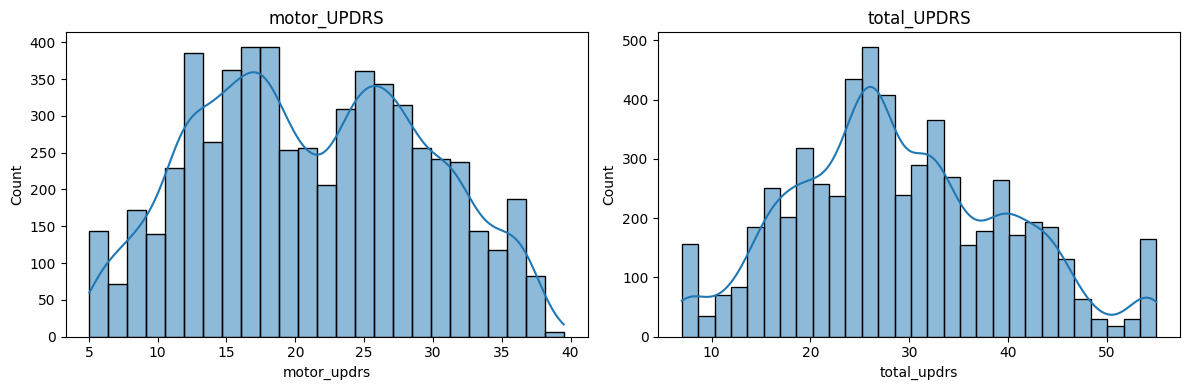

In [7]:
# Distribution of targets
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['motor_updrs'], kde=True, ax=axes[0])
axes[0].set_title('motor_UPDRS')
sns.histplot(df['total_updrs'], kde=True, ax=axes[1])
axes[1].set_title('total_UPDRS')
plt.tight_layout()
plt.show()


# Prepare Features and Targets

In [8]:
# Features: all columns except subject#, motor_UPDRS, total_UPDRS
# We keep subject# for grouping, but it will be dropped before training.
feature_cols = [col for col in df.columns if col not in ['subject', 'motor_updrs', 'total_updrs']]
X = df[feature_cols].copy()
y_motor = df['motor_updrs']
y_total = df['total_updrs']
groups = df['subject']

print("\nFeatures:", feature_cols)
print("Number of features:", len(feature_cols))


Features: ['age', 'sex', 'test_time', 'jitter', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp', 'shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5', 'shimmer_apq11', 'shimmer_dda', 'nhr', 'hnr', 'rpde', 'dfa', 'ppe']
Number of features: 19


# Subject-wise Train/Test Split

In [9]:
# We'll use 30 subjects for training, 12 for testing (as an example)
unique_subjects = groups.unique()
np.random.seed(42)
train_subjects = np.random.choice(unique_subjects, size=30, replace=False)
test_subjects = [s for s in unique_subjects if s not in train_subjects]

train_mask = groups.isin(train_subjects)
test_mask = groups.isin(test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_motor_train, y_motor_test = y_motor[train_mask], y_motor[test_mask]
y_total_train, y_total_test = y_total[train_mask], y_total[test_mask]

print(f"\nTrain subjects: {sorted(train_subjects)}")
print(f"Test subjects: {sorted(test_subjects)}")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Train subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(20), np.int64(22), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(40), np.int64(41), np.int64(42)]
Test subjects: [np.int64(4), np.int64(8), np.int64(11), np.int64(15), np.int64(19), np.int64(21), np.int64(23), np.int64(24), np.int64(29), np.int64(35), np.int64(38), np.int64(39)]
Training samples: 4136, Test samples: 1739


#  Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation (Separate for motor and total)

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_motor = {}
results_total = {}

print("\n" + "="*60)
print("Model Performance on Test Set")
print("="*60)

for name, model in models.items():
    # Train and predict for motor_UPDRS
    model_motor = model.__class__()  # fresh copy
    model_motor.fit(X_train_scaled, y_motor_train)
    y_pred_motor = model_motor.predict(X_test_scaled)
    results_motor[name] = evaluate_model(y_motor_test, y_pred_motor, name)

    # Train and predict for total_UPDRS
    model_total = model.__class__()
    model_total.fit(X_train_scaled, y_total_train)
    y_pred_total = model_total.predict(X_test_scaled)
    results_total[name] = evaluate_model(y_total_test, y_pred_total, name)

    print(f"\n{name}:")
    print(f"  motor_UPDRS  -> MAE: {results_motor[name]['MAE']:.3f}, RMSE: {results_motor[name]['RMSE']:.3f}, R2: {results_motor[name]['R2']:.3f}")
    print(f"  total_UPDRS  -> MAE: {results_total[name]['MAE']:.3f}, RMSE: {results_total[name]['RMSE']:.3f}, R2: {results_total[name]['R2']:.3f}")


Model Performance on Test Set

Linear Regression:
  motor_UPDRS  -> MAE: 5.814, RMSE: 7.188, R2: 0.044
  total_UPDRS  -> MAE: 8.041, RMSE: 10.838, R2: -0.065

Random Forest:
  motor_UPDRS  -> MAE: 7.439, RMSE: 9.088, R2: -0.528
  total_UPDRS  -> MAE: 14.369, RMSE: 16.105, R2: -1.351

XGBoost:
  motor_UPDRS  -> MAE: 8.195, RMSE: 9.453, R2: -0.653
  total_UPDRS  -> MAE: 13.493, RMSE: 15.558, R2: -1.195

SVR:
  motor_UPDRS  -> MAE: 6.545, RMSE: 8.128, R2: -0.222
  total_UPDRS  -> MAE: 9.122, RMSE: 11.824, R2: -0.268


# Cross-Validation (GroupKFold by subject)

In [12]:
print("\n" + "="*60)
print("Cross-Validation Results (GroupKFold, 5 folds)")
print("="*60)

gkf = GroupKFold(n_splits=5)

for name, model in models.items():
    # Create a pipeline that scales then applies the model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # motor_UPDRS CV
    cv_scores_motor = cross_val_score(pipeline, X, y_motor, cv=gkf, groups=groups, scoring='r2')
    print(f"\n{name}:")
    print(f"  motor_UPDRS R2 CV: {cv_scores_motor.mean():.3f} ± {cv_scores_motor.std():.3f}")

    # total_UPDRS CV
    cv_scores_total = cross_val_score(pipeline, X, y_total, cv=gkf, groups=groups, scoring='r2')
    print(f"  total_UPDRS R2 CV: {cv_scores_total.mean():.3f} ± {cv_scores_total.std():.3f}")


Cross-Validation Results (GroupKFold, 5 folds)

Linear Regression:
  motor_UPDRS R2 CV: -0.395 ± 0.275
  total_UPDRS R2 CV: -0.312 ± 0.320

Random Forest:
  motor_UPDRS R2 CV: -0.773 ± 0.985
  total_UPDRS R2 CV: -1.304 ± 1.576

XGBoost:
  motor_UPDRS R2 CV: -0.649 ± 0.953
  total_UPDRS R2 CV: -1.144 ± 1.453

SVR:
  motor_UPDRS R2 CV: -0.576 ± 0.409
  total_UPDRS R2 CV: -0.527 ± 0.392


# Summary Table

In [13]:

print("\n" + "="*60)
print("Summary Table (Test Set)")
print("="*60)

summary = pd.DataFrame({
    'Model': list(results_motor.keys()),
    'motor_MAE': [results_motor[m]['MAE'] for m in results_motor],
    'motor_RMSE': [results_motor[m]['RMSE'] for m in results_motor],
    'motor_R2': [results_motor[m]['R2'] for m in results_motor],
    'total_MAE': [results_total[m]['MAE'] for m in results_total],
    'total_RMSE': [results_total[m]['RMSE'] for m in results_total],
    'total_R2': [results_total[m]['R2'] for m in results_total],
})
print(summary.to_string(index=False))

# Optional: Save results to CSV
summary.to_csv('parkinsons_benchmark_results.csv', index=False)

print("\nBenchmark completed.")


Summary Table (Test Set)
            Model  motor_MAE  motor_RMSE  motor_R2  total_MAE  total_RMSE  total_R2
Linear Regression   5.813754    7.187647  0.044219   8.041064   10.837871 -0.064911
    Random Forest   7.439445    9.087771 -0.527917  14.369149   16.104733 -1.351432
          XGBoost   8.194959    9.453250 -0.653284  13.492962   15.558250 -1.194557
              SVR   6.544653    8.127709 -0.222141   9.121646   11.824418 -0.267608

Benchmark completed.
